# AI-Driven Phishing Email Detection Using NLP and Machine Learning

This notebook demonstrates the complete machine learning pipeline for detecting phishing emails. It utilizes a hybrid approach, combining:
1. **Linguistic Semantics**: Term Frequency-Inverse Document Frequency (TF-IDF) and Word2Vec averaged word embeddings.
2. **Structural Metadata**: Behavioral signals extracted from the raw email (URL count, urgency indicators, CAPS ratios, exclamation mark density, etc.).

We train and tune four different classifiers: **Logistic Regression**, **Random Forest**, **Multinomial Naive Bayes**, and a **Neural Network (MLP)**, and construct a **Soft-Voting Ensemble** combining them.

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Add src to sys.path
sys.path.append('../src')

# Import pipeline elements
from data_loader import download_dataset
from preprocessing import preprocess_dataset
from models import train_and_tune_models
from evaluate import evaluate_models

## Step 1: Run the End-to-End ML Pipeline
We run the orchestration pipeline which downloads (or generates synthetic) emails, preprocesses the text, extracts hybrid features, tunes model parameters with Stratified 5-Fold Cross-Validation, and evaluates them on a holdout test set.

In [2]:
# Run the pipeline
from train_pipeline import run_pipeline
df_results = run_pipeline()

## Step 2: Comparative Metric Analysis
Let's compare the metrics (Accuracy, Precision, Recall, F1-Score) achieved by the models on the holdout test set.

In [3]:
# Display summary results
df_results

Model,Accuracy,Precision,Recall,F1-Score
LogisticRegression,0.982891,0.972789,0.981693,0.977221
RandomForest,0.981751,0.971991,0.979405,0.975684
NaiveBayes,0.971486,0.965411,0.958047,0.961715
NeuralNetwork,0.983747,0.980828,0.975591,0.978203
VotingEnsemble,0.985173,0.980901,0.979405,0.980153


## Step 3: Visualize Confusion Matrices and Feature Importances
Let's visualize the confusion matrix and feature importances for the best performing model (Random Forest).

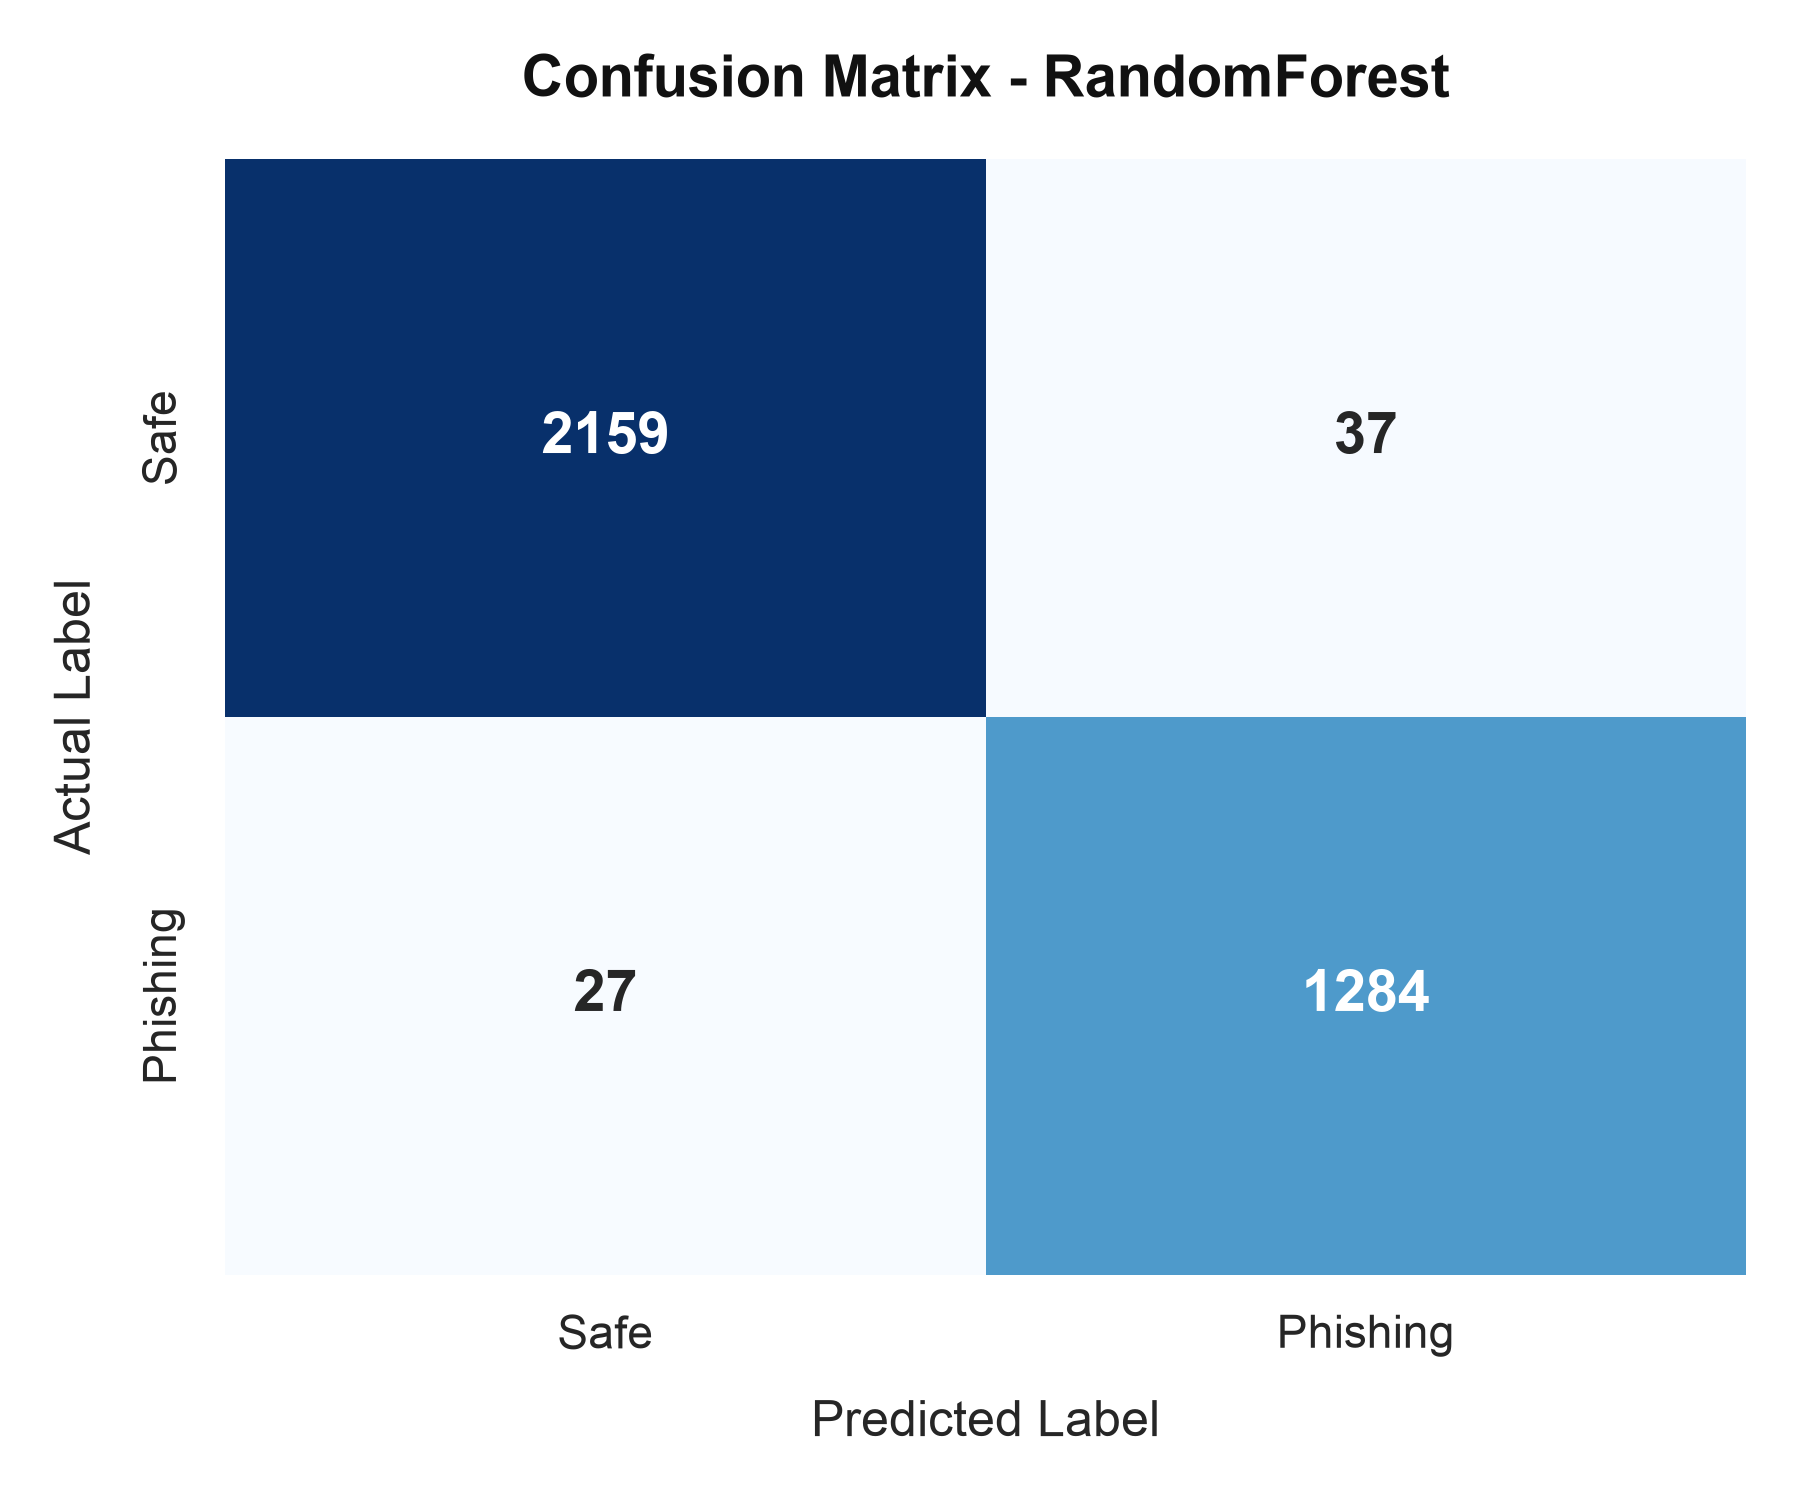

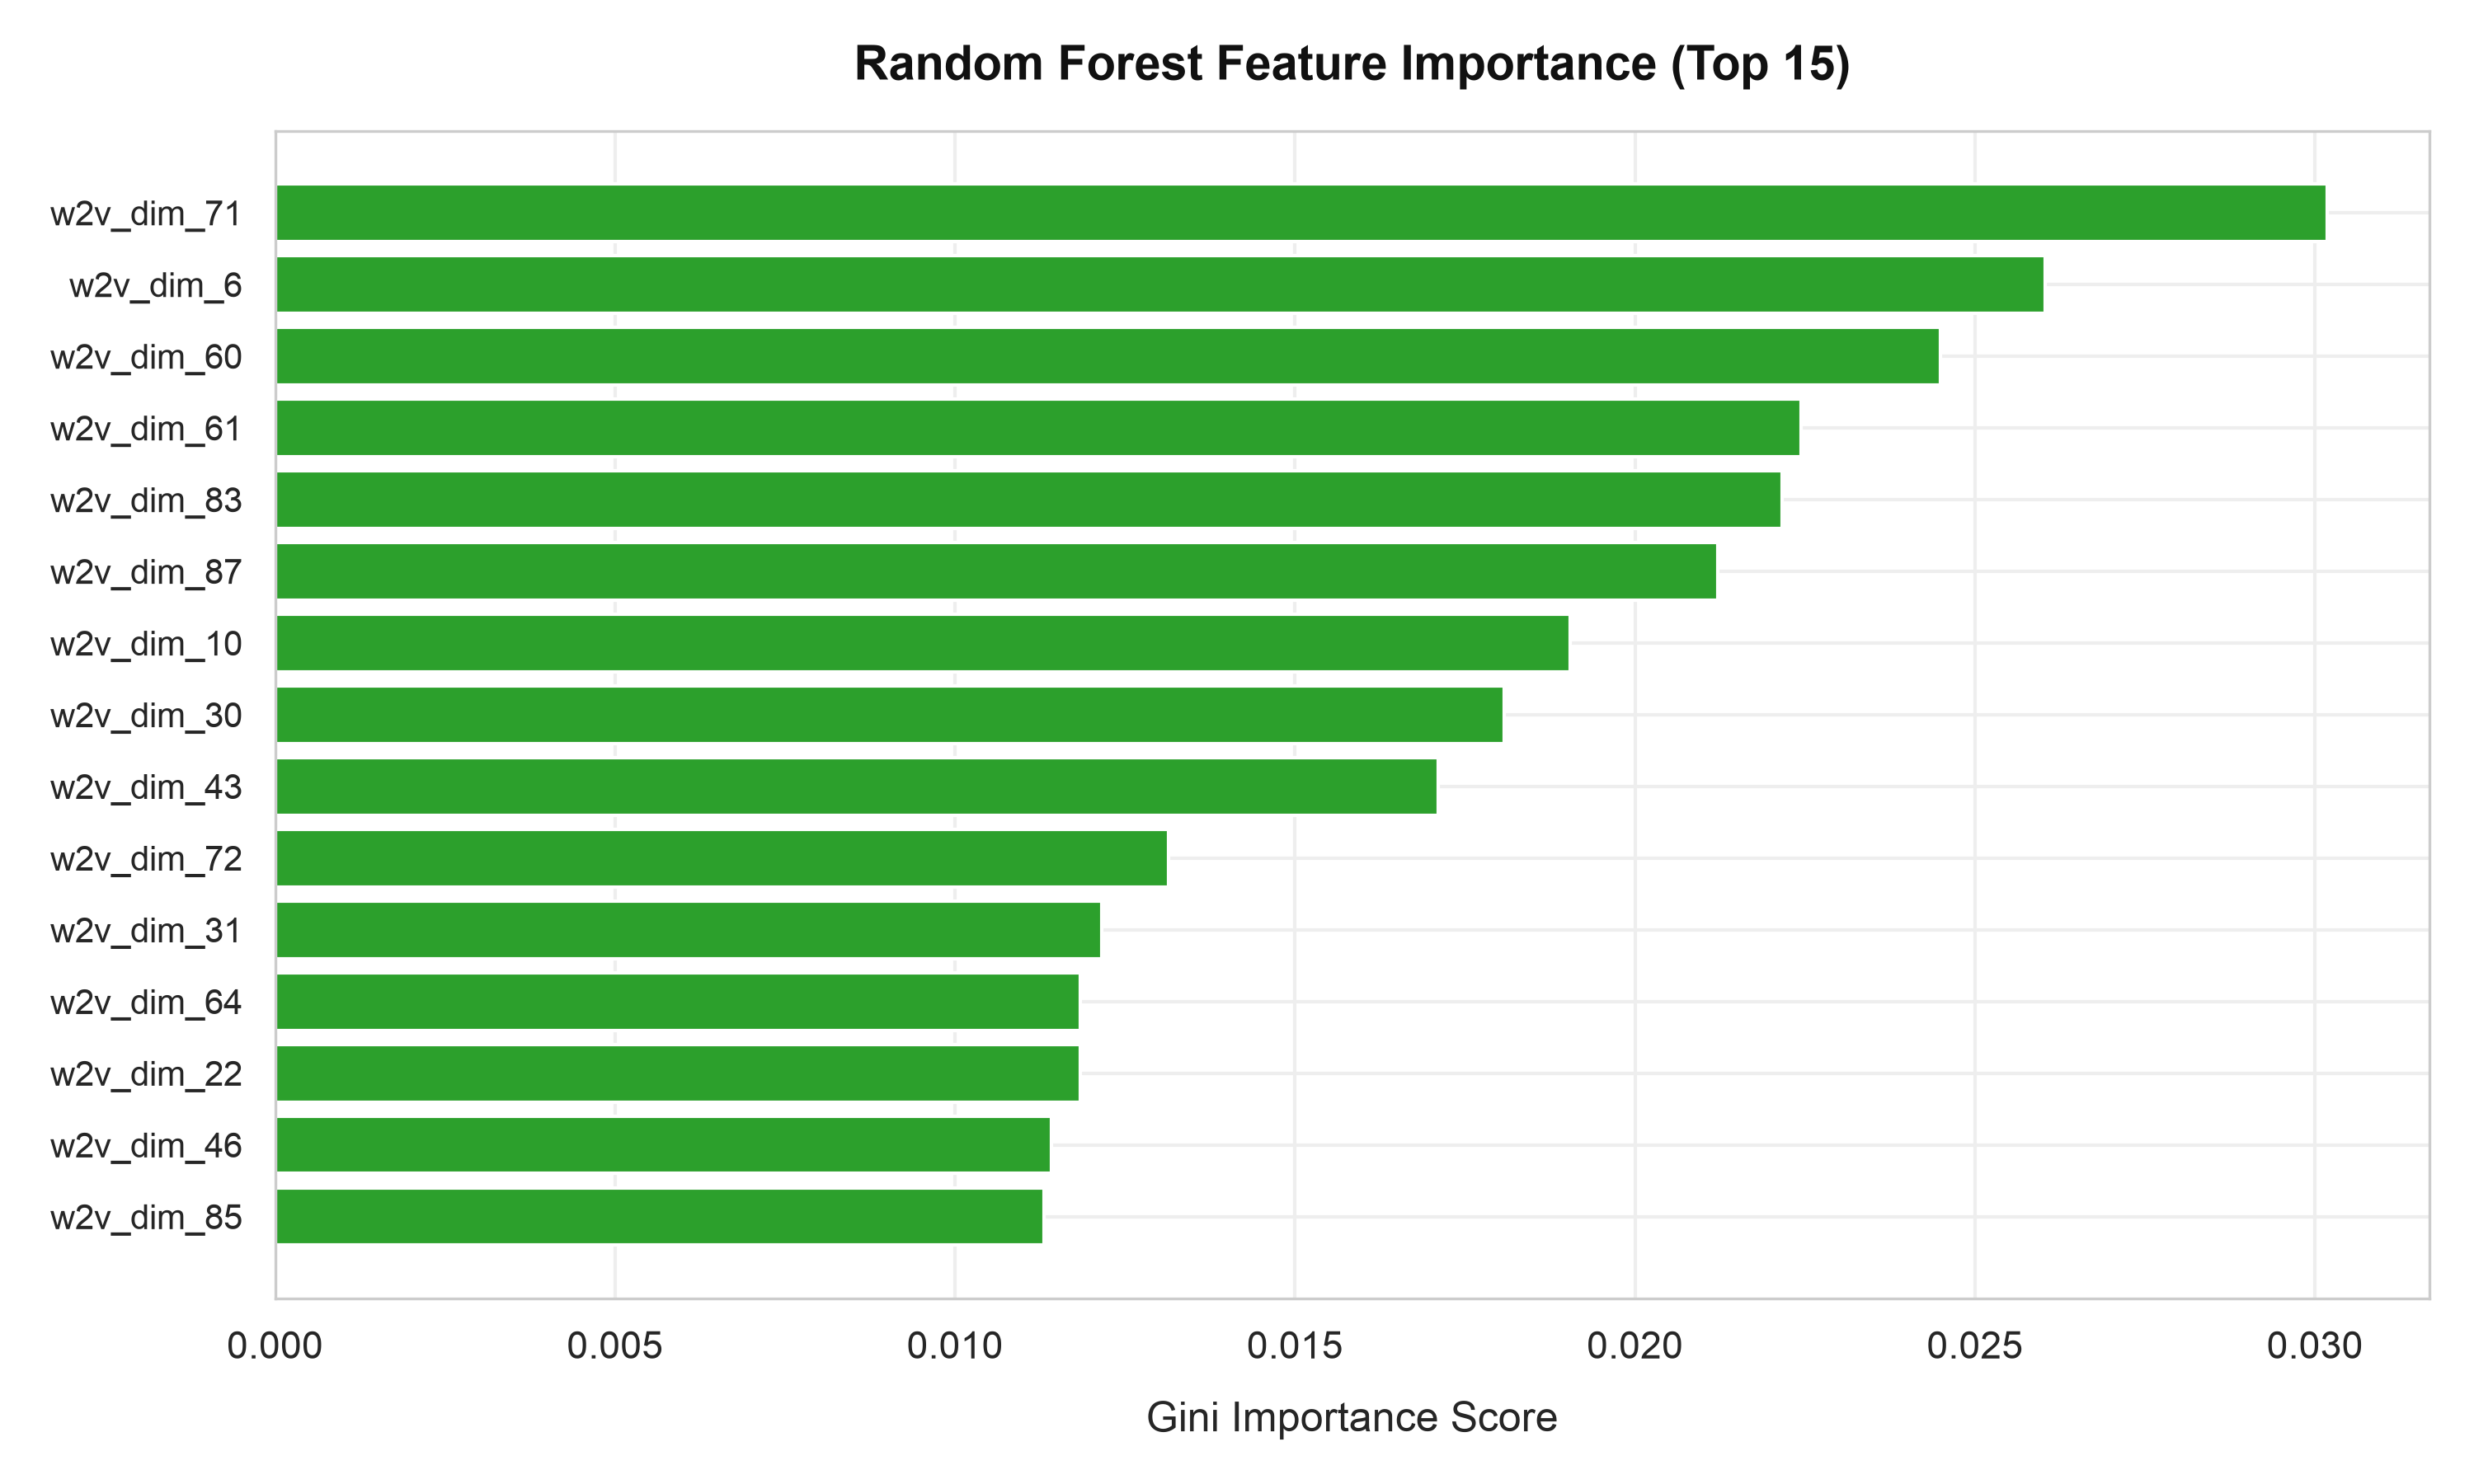

In [4]:
# Display figures generated by the evaluation script
rf_cm_path = '../reports/figures/confusion_matrix_RandomForest.png'
rf_fi_path = '../reports/figures/feature_importance_RandomForest.png'

if os.path.exists(rf_cm_path):
    plt.figure(figsize=(7, 7))
    img = plt.imread(rf_cm_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

if os.path.exists(rf_fi_path):
    plt.figure(figsize=(9, 7))
    img = plt.imread(rf_fi_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

## Step 4: Interactive Live Prediction Test
You can test the trained models by entering custom email text below:

In [5]:
from preprocessing import clean_text

# Paste test email body
sample_email = """
URGENT: Your PayPal account has been limited! We detected unusual access from a foreign IP address.
To verify your account and restore access, click here: http://secure-paypal-resolution-9238.xyz/login
Failure to verify within 12 hours will result in permanent suspension of your balance.
"""

# Load models and extractor
extractor = joblib.load('../models/feature_extractor.joblib')
ensemble_model = joblib.load('../models/VotingEnsemble_best_model.joblib')

# Clean and transform
cleaned_sample = clean_text(sample_email)
sample_df = pd.DataFrame([{"Email Text": sample_email, "Cleaned Text": cleaned_sample}])
features = extractor.transform(sample_df)

# Predict
pred = ensemble_model.predict(features)[0]
probs = ensemble_model.predict_proba(features)[0]

print(f"Prediction: {'PHISHING' if pred == 1 else 'LEGITIMATE'}")
print(f"Confidence: {probs[pred]*100:.2f}%")

Prediction: PHISHING
Confidence: 85.71%
